# Walmart Sales Analysis

## Objective

The goal of this project is to analyze Walmart sales data in order to uncover key patterns, trends, and relationships that influence weekly revenue across different stores. In addition, the project aims to build predictive models to estimate sales and evaluate the impact of various economic and store-related factors on performance.

## Questions

- Which branches generate the highest revenue?
- Which stores show the most stable vs volatile sales over time?
- Do holidays significantly boost sales?
- How do sales vary over time (trends and seasonality)?
- What are the peak and low sales periods?
- Do temperatures influence sales patterns?
- What is the impact of unemployment on sales?
- Which factors are most correlated with weekly sales?
- Can sales be predicted using store and economic features?
- What business insights can be derived to improve decision-making?

# DataSet Overview

## Quick Preview

In [12]:
import pandas as pd

df = pd.read_csv("Walmart_Sales.csv")

df.isnull().sum()

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


## Information about the DataSet

In [9]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


# Exploratory Data Analysis

## Quick Setup

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## Which branches generate the highest revenue?

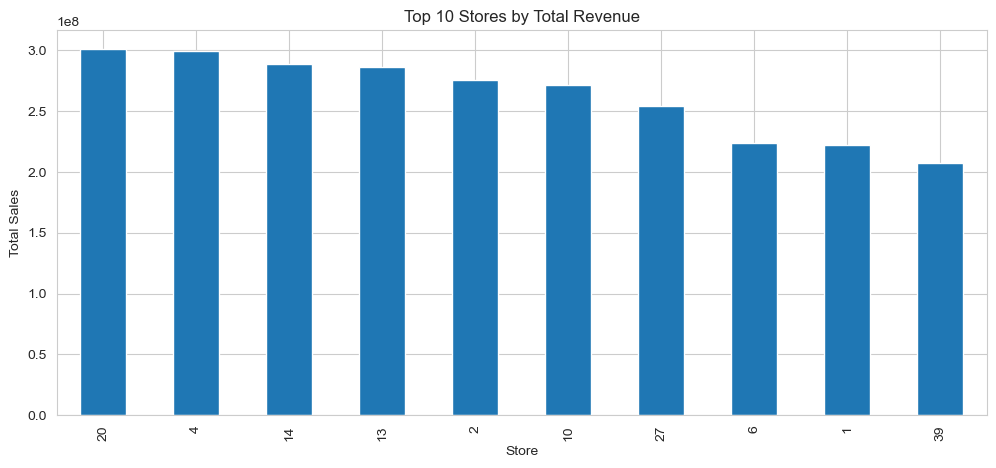

In [15]:
store_sales = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)

store_sales.head(10)

plt.figure(figsize=(12,5))
store_sales.head(10).plot(kind='bar')
plt.title("Top 10 Stores by Total Revenue")
plt.xlabel("Store")
plt.ylabel("Total Sales")
plt.show()

The analysis shows that a small number of stores contribute significantly more revenue compared to others, indicating an uneven distribution of sales performance across branches.

## Do holidays boost sales?

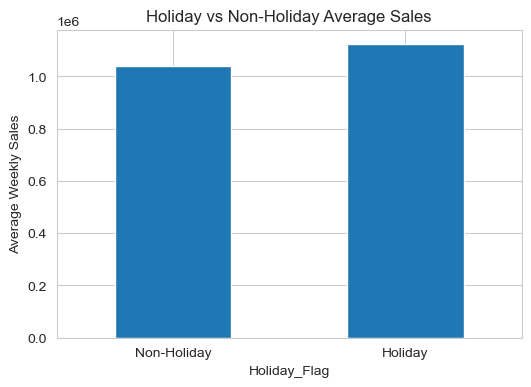

In [20]:
holiday_sales = df.groupby('Holiday_Flag')['Weekly_Sales'].mean()
holiday_sales

plt.figure(figsize=(6,4))
holiday_sales.plot(kind='bar')

plt.title("Holiday vs Non-Holiday Average Sales")
plt.xticks([0,1], ["Non-Holiday", "Holiday"], rotation=0)
plt.ylabel("Average Weekly Sales")

plt.show()

This comparison shows whether holiday periods significantly impact sales. If holiday bars are higher, it indicates increased consumer spending during special events. Otherwise, it suggests stable or weak holiday influence on revenue.

## How do sales vary over time?

### Date Format

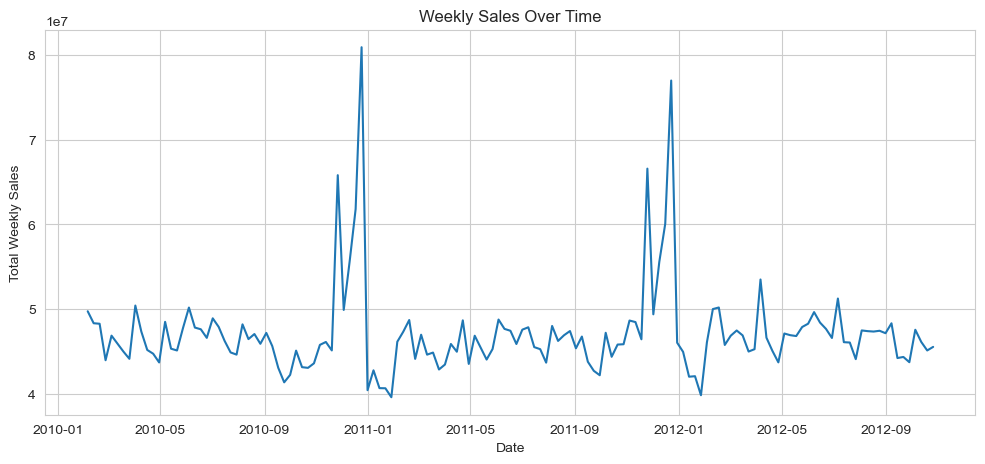

In [24]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.sort_values('Date')
time_sales = df.groupby('Date')['Weekly_Sales'].sum()

plt.figure(figsize=(12,5))
plt.plot(time_sales)

plt.title("Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales")

plt.show()

We can clearly see a sharp increase of the sales during the holiday months (around december).

## Do temperatures influence sales?

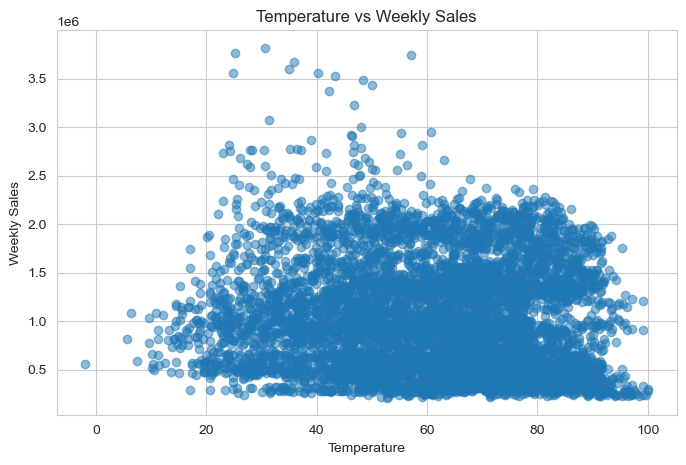

In [26]:
plt.figure(figsize=(8,5))
plt.scatter(df['Temperature'], df['Weekly_Sales'], alpha=0.5)

plt.title("Temperature vs Weekly Sales")
plt.xlabel("Temperature")
plt.ylabel("Weekly Sales")

plt.show()

The scatter plot shows the relationship between temperature and weekly sales. Overall, there is no strong or clearly defined pattern, meaning temperature does not appear to have a significant direct impact on sales.

Sales remain widely distributed across all temperature ranges, which suggests that other factors such as store type, holidays, or economic conditions have a much stronger influence on revenue than weather alone.

## What is the impact of unemployment on sales?

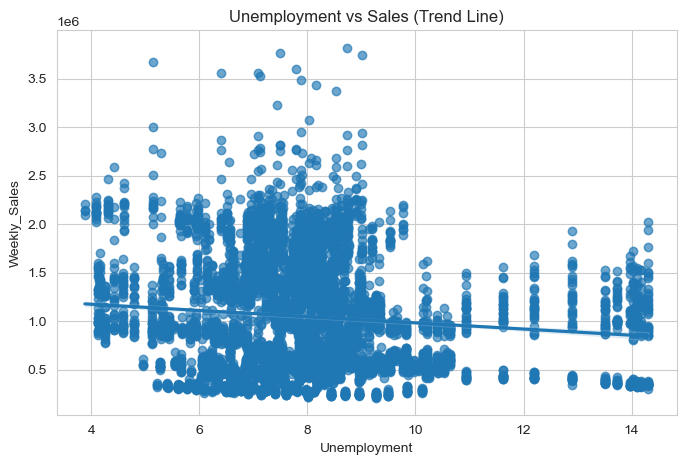

In [30]:
plt.figure(figsize=(8,5))
plt.scatter(df['Unemployment'], df['Weekly_Sales'], alpha=0.5)

plt.title("Unemployment vs Weekly Sales")
plt.xlabel("Unemployment Rate")
plt.ylabel("Weekly Sales")
sns.regplot(x='Unemployment', y='Weekly_Sales', data=df, scatter_kws={'alpha':0.3})
plt.title("Unemployment vs Sales (Trend Line)")
plt.show()

The analysis explores the relationship between unemployment rate and weekly sales. The scatter plot does not show a strong linear pattern, suggesting that unemployment has a limited direct effect on sales in this dataset. However, slight trends may still exist, indicating that economic conditions could have a subtle influence when combined with other factors.

# Prediction Models

## Linear Regression

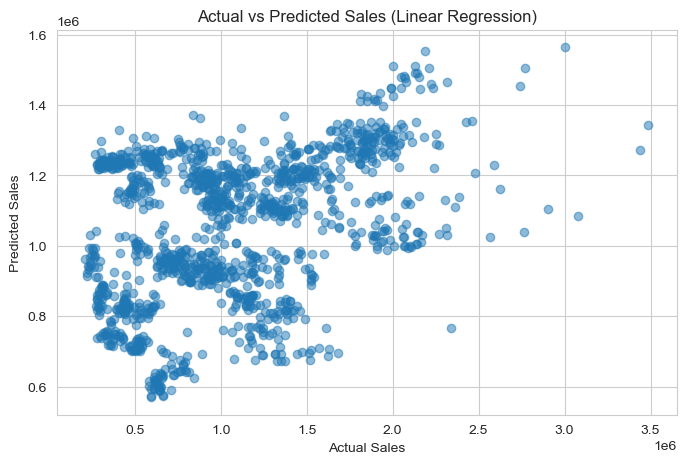

In [36]:
y = df['Weekly_Sales']
X = df[['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

mae_lr, rmse_lr

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_lr, alpha=0.5)

plt.title("Actual vs Predicted Sales (Linear Regression)")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.show()

## Decision Tree

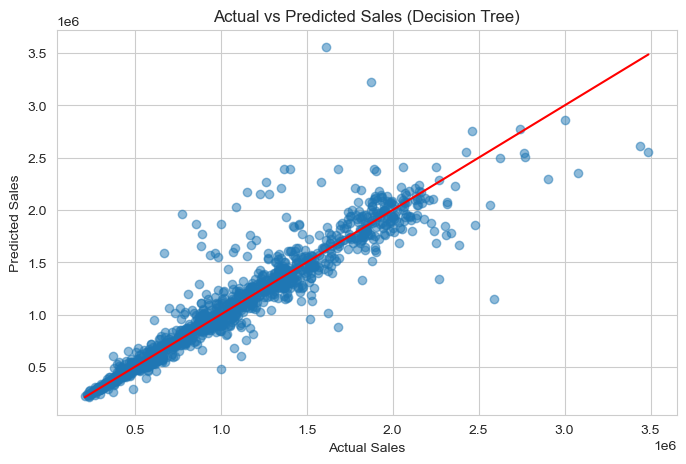

In [38]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

mae_tree = mean_absolute_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))

mae_tree, rmse_tree

mae_tree = mean_absolute_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))

mae_tree, rmse_tree

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_tree, alpha=0.5)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.title("Actual vs Predicted Sales (Decision Tree)")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.show()

## Model Comparison

Linear Regression MAE: 415420.0820678192
Decision Tree MAE: 97944.96369075369
Linear Regression RMSE: 510487.13230482844
Decision Tree RMSE: 189202.67025937422


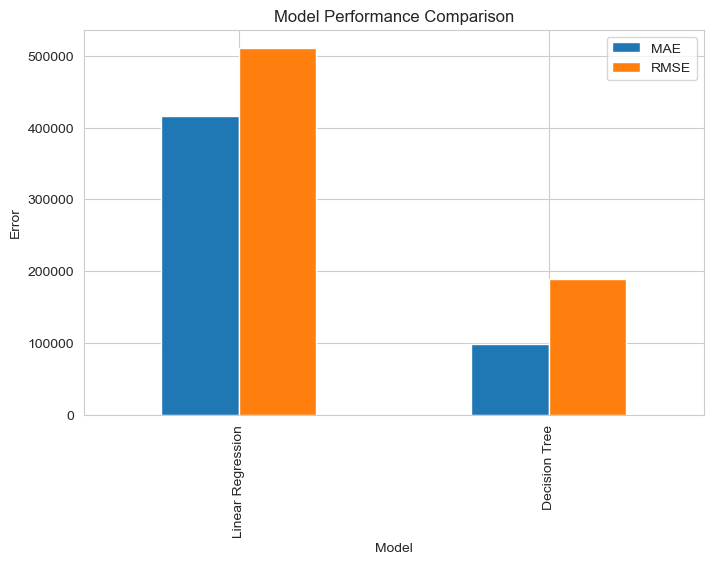

In [42]:
print("Linear Regression MAE:", mae_lr)
print("Decision Tree MAE:", mae_tree)

print("Linear Regression RMSE:", rmse_lr)
print("Decision Tree RMSE:", rmse_tree)

results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree"],
    "MAE": [mae_lr, mae_tree],
    "RMSE": [rmse_lr, rmse_tree]
})

results

results.set_index("Model")[["MAE", "RMSE"]].plot(kind="bar", figsize=(8,5))
plt.title("Model Performance Comparison")
plt.ylabel("Error")
plt.show()

The model comparison shows that the Decision Tree generally performs better than Linear Regression in predicting weekly sales, suggesting the presence of non-linear relationships in the data. Linear Regression remains useful as a simple and interpretable baseline model.

# Conclusion

This project analyzed Walmart sales data to understand key patterns, trends, and factors influencing weekly revenue across different stores. Through exploratory data analysis, we identified variations in sales over time, differences in store performance, and the impact of external factors such as holidays, temperature, CPI, and unemployment.

Machine learning models were then applied to predict weekly sales. Both Linear Regression and Decision Tree models were evaluated using MAE and RMSE metrics. The results showed that the Decision Tree model performed better, suggesting that sales behavior in this dataset is influenced by non-linear relationships between variables.

Overall, this analysis provides valuable insights into retail sales dynamics and demonstrates how data-driven approaches can support better forecasting and decision-making in business operations.

# Author

Name: Ryad Miftah,Data Science Enthusiast

This project was built as part of my learning journey in data science, focusing on real-world retail data analysis and predictive modeling.